# HOMEWORK 10

In this homework, you are going to use and compare two different trackers (of your liking) and compare the results.

### Step 1

Decide what video you are going to use for this homework, select an object and generate the template. You can use any video you want (your own, from Youtube, etc.) and track any object you want (e.g. a car, a pedestrian, etc.).

In [1]:
import cv2
from matplotlib import pyplot as plt

In [2]:
def plot_grid(images, bboxes, grid_size=(5, 5)):
    """
    Plot a grid of images with optional bounding boxes.

    This function displays a grid of images, with the option to overlay bounding boxes
    on each image. It is useful for visualizing the results of object detection algorithms.

    Parameters
    ----------
    images : list
        A list of images to display.
    bboxes : list | None, optional
        A list of bounding boxes for each image, by default None
    grid_size : tuple, optional
        The number of rows and columns in the grid, by default (2, 2)
    """
    ncols, nrows = grid_size

    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 15))
    axes = axes.flatten()

    for image, bbox, ax in zip(images, bboxes, axes):
        img_to_plot = image.copy()
        if bbox is not None:
            x1, y1 = bbox[0], bbox[1]
            width, height = bbox[2], bbox[3]
            cv2.rectangle(img_to_plot, (x1, y1), (x1+width, y1+height), (255, 0, 0), 2)
        ax.imshow(img_to_plot)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

def get_video_frames(path, n=None):
    cap = cv2.VideoCapture(path)
    frames = []

    if n is None:
        n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    while cap.isOpened() and len(frames) <= n:
        ret, frame = cap.read()

        if ret == True:
            frames.append(frame)
        else:
            break

    return frames

In [3]:
frames = get_video_frames("./data/video.mp4")
len(frames)

250

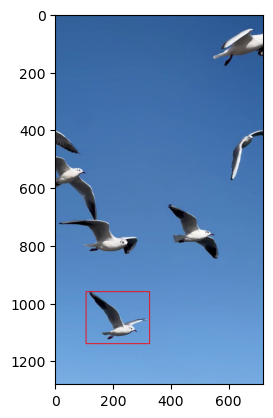

In [4]:
bbox = (107, 960, 220, 180)
img = cv2.cvtColor(frames[0], cv2.COLOR_BGR2RGB)
image_with_bbox = cv2.rectangle(img, (bbox[0], bbox[1]), (bbox[0] + bbox[2], bbox[1] + bbox[3]), color=(255, 0, 0), thickness=2)
plt.imshow(image_with_bbox)

### Step 2

Initialize a tracker (e.g. KCF).

In [5]:
tracker = cv2.TrackerKCF_create()
ok = tracker.init(img.copy(), bbox)

### Step 3

Run the tracker on the video and the selected object. Run the tracker for around 10-15 frames.

In [6]:
def track(frames):
    images, bboxes = [], []

    for frame in frames:
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        ok, bbox = tracker.update(image)
        images.append(image)
        if ok:
            bboxes.append(bbox)
        else:
            bboxes.append(None)

    return images, bboxes

images, bboxes = track(frames[1::5][:25])

### Step 4

For each frame, print the bounding box on the image and save it.

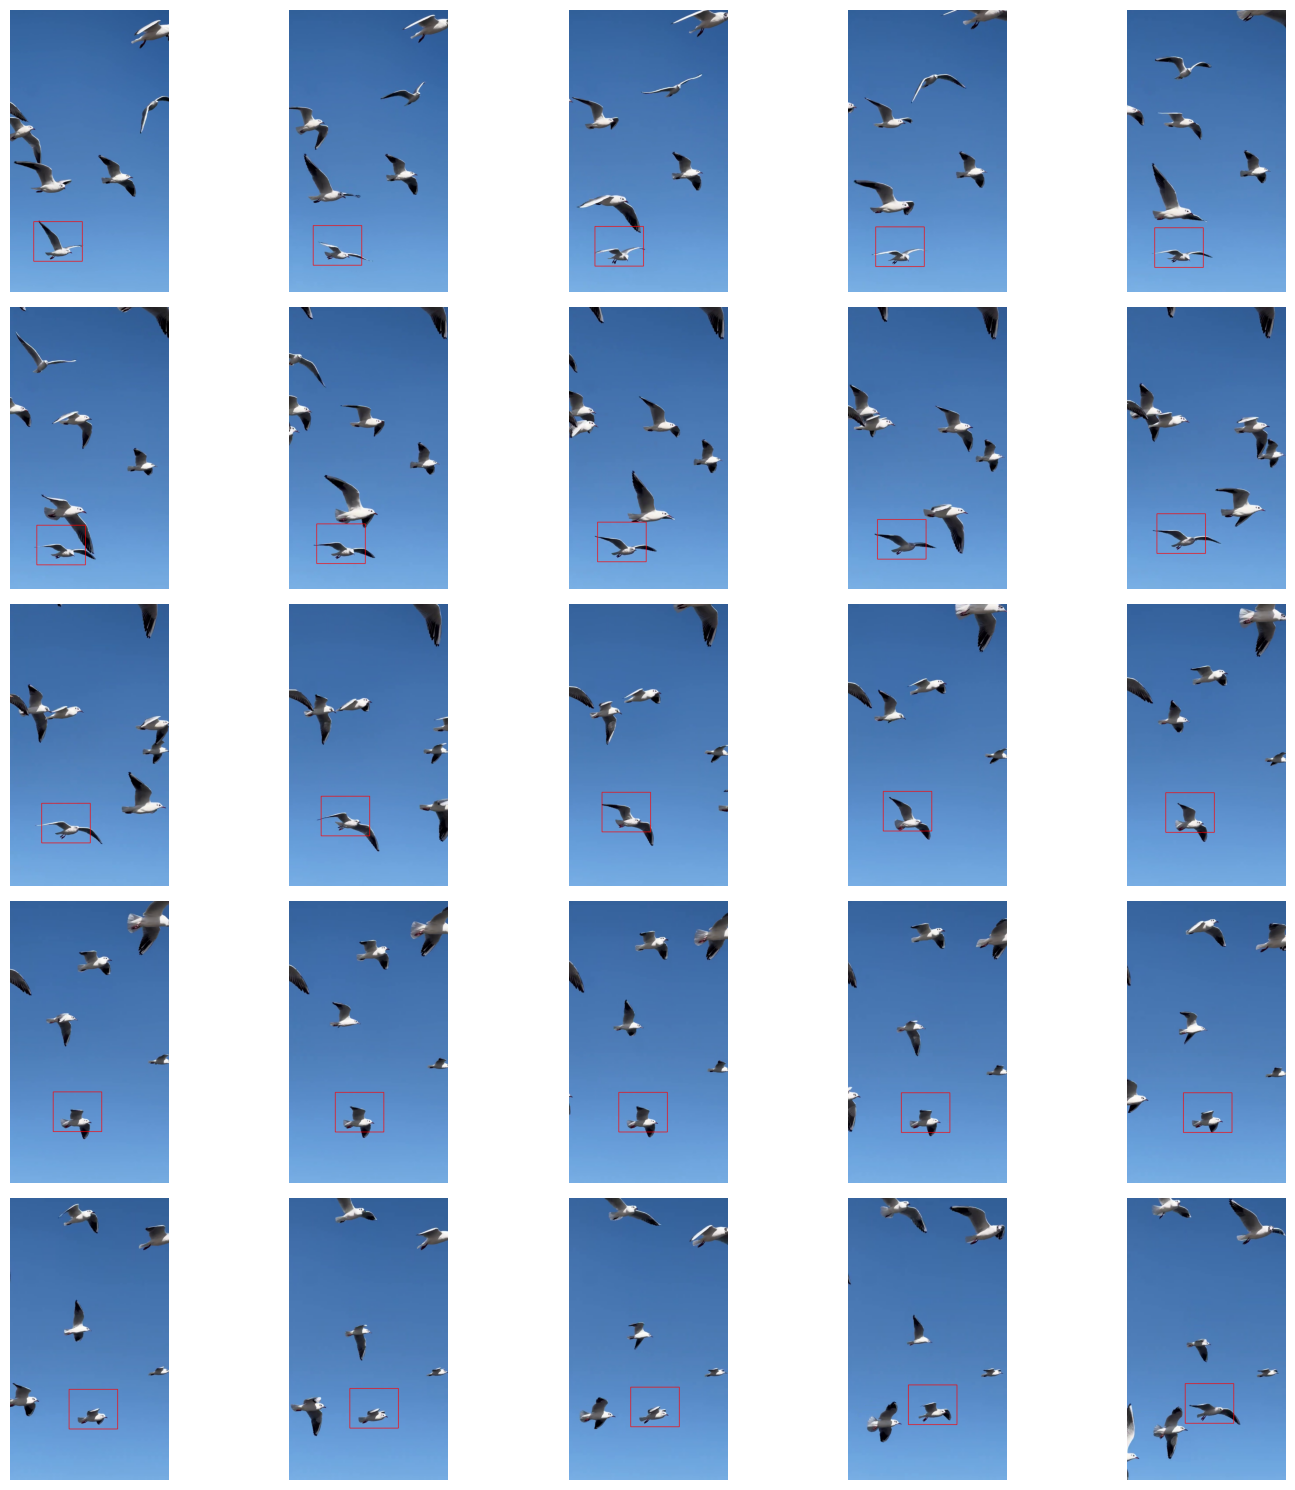

In [7]:
plot_grid(images, bboxes)

### Step 5

Select a different tracker (e.g. CSRT) and repeat steps 2, 3 and 4.

#### CSRT

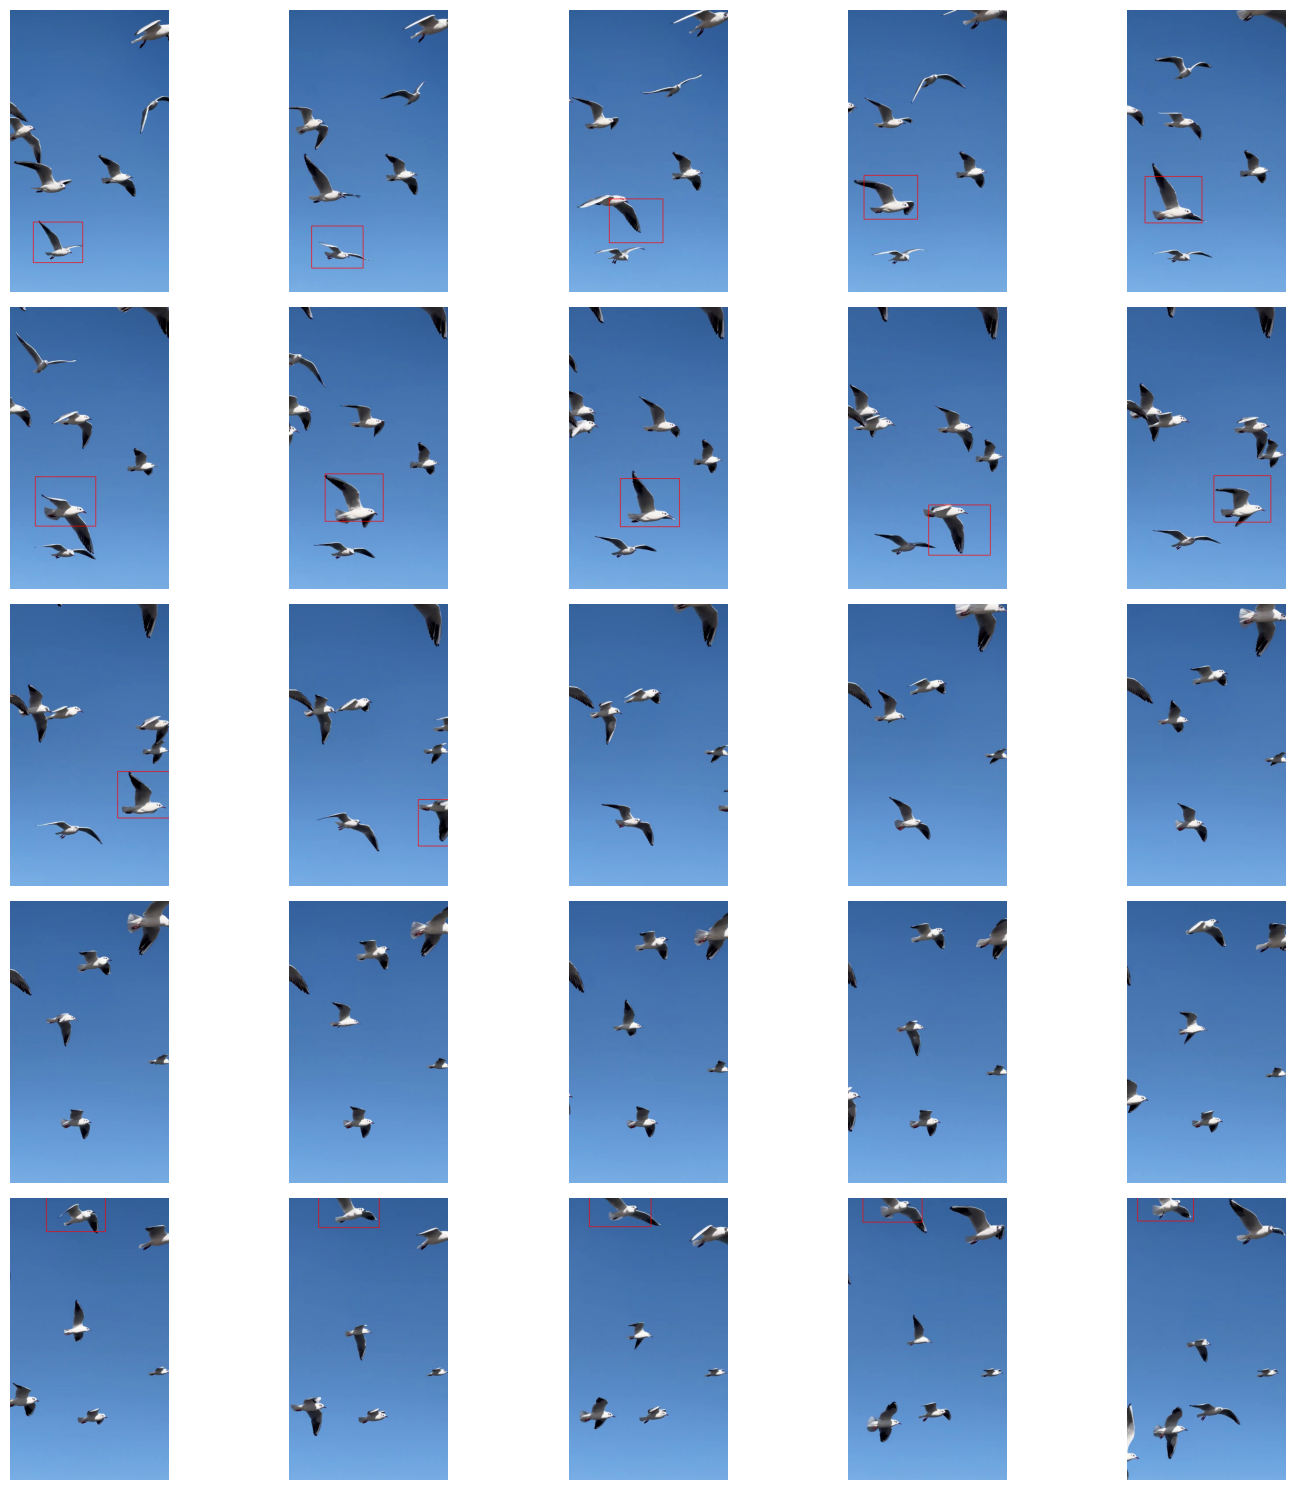

In [8]:
tracker = cv2.TrackerCSRT_create()
tracker.init(img.copy(), bbox)
images, bboxes = track(frames[1::5][:25])
plot_grid(images, bboxes)

#### MIL

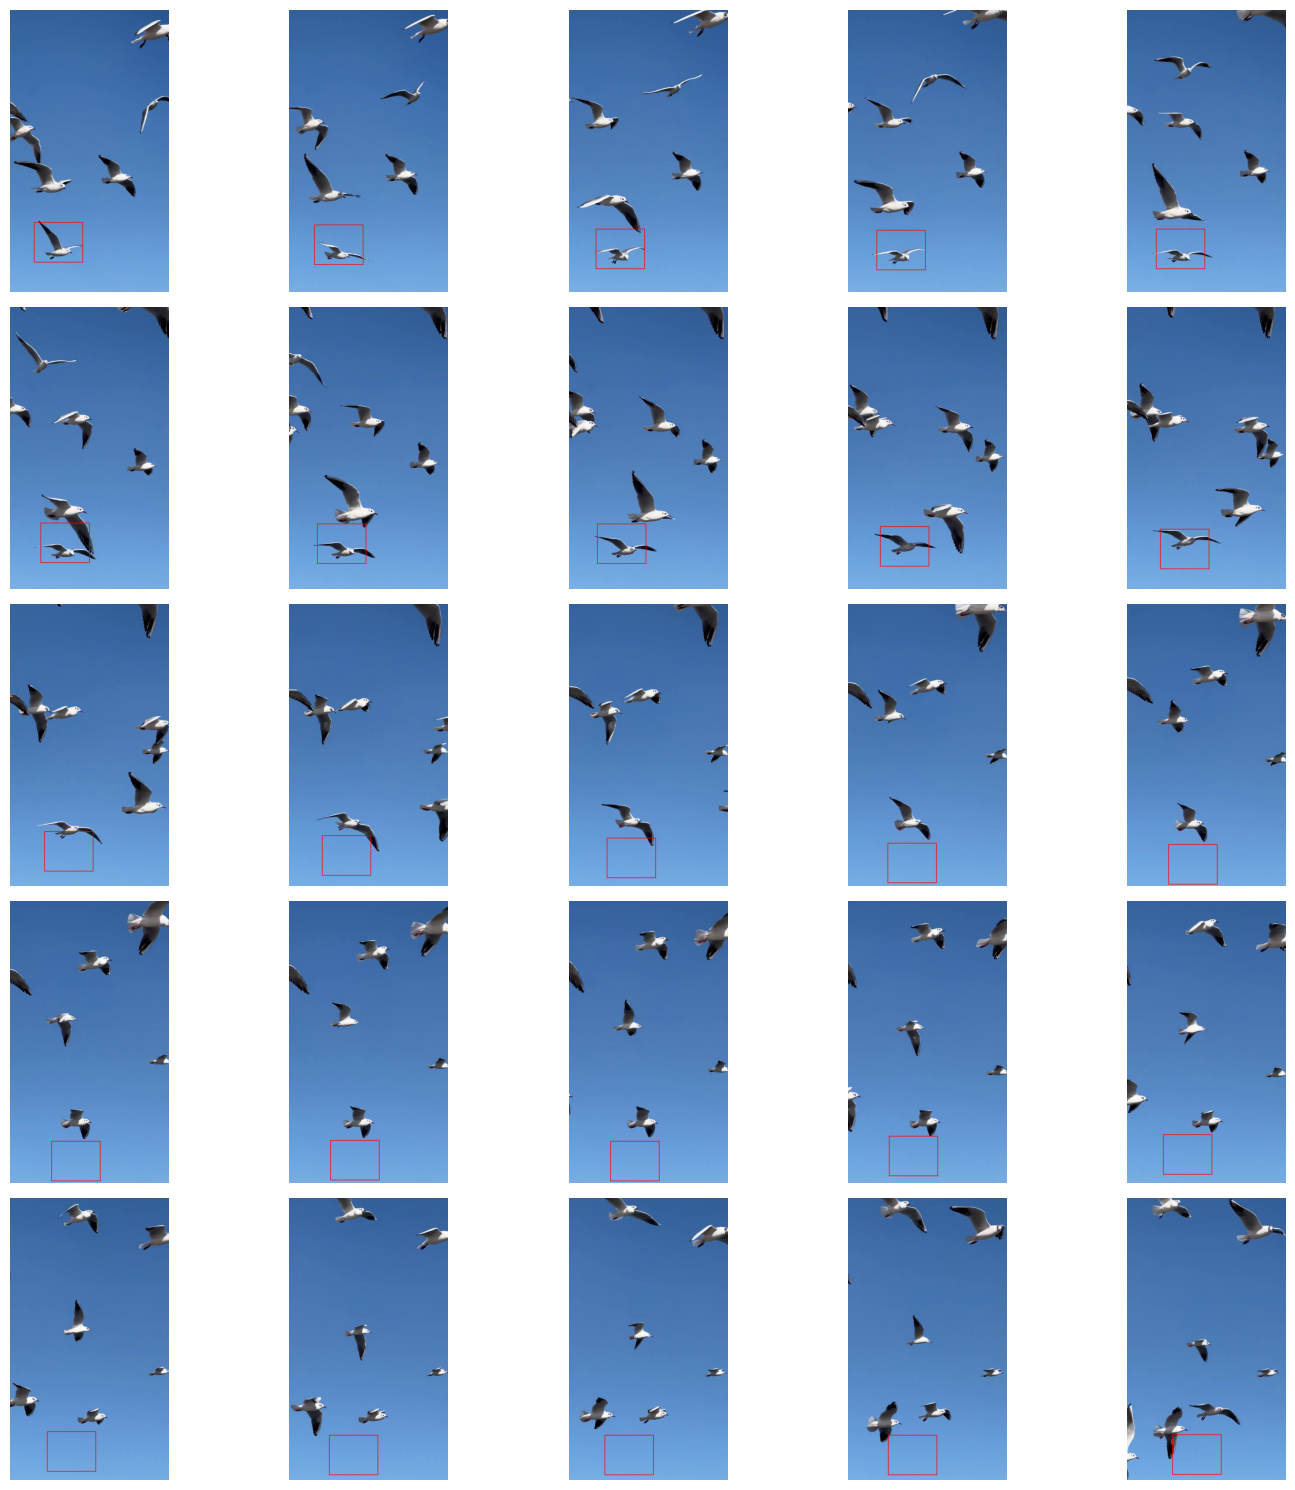

In [9]:
tracker = cv2.TrackerMIL_create()
tracker.init(img.copy(), bbox)
images, bboxes = track(frames[1::5][:25])
plot_grid(images, bboxes)

### Step 6

Compare the results:

Do you see any differences? If so, what are they?
Does one tracker perform better than the other? In what way?

I took each 5th frame out of 250 frames and then took the first 25 frames. In this scenario, only KCF was able to track the bird correctly. CSRT switched to another bird pretty quickly, MIL at first tracked the bird correctly, but then started to track the empty space.